Plotting Time-Series grid for all files...


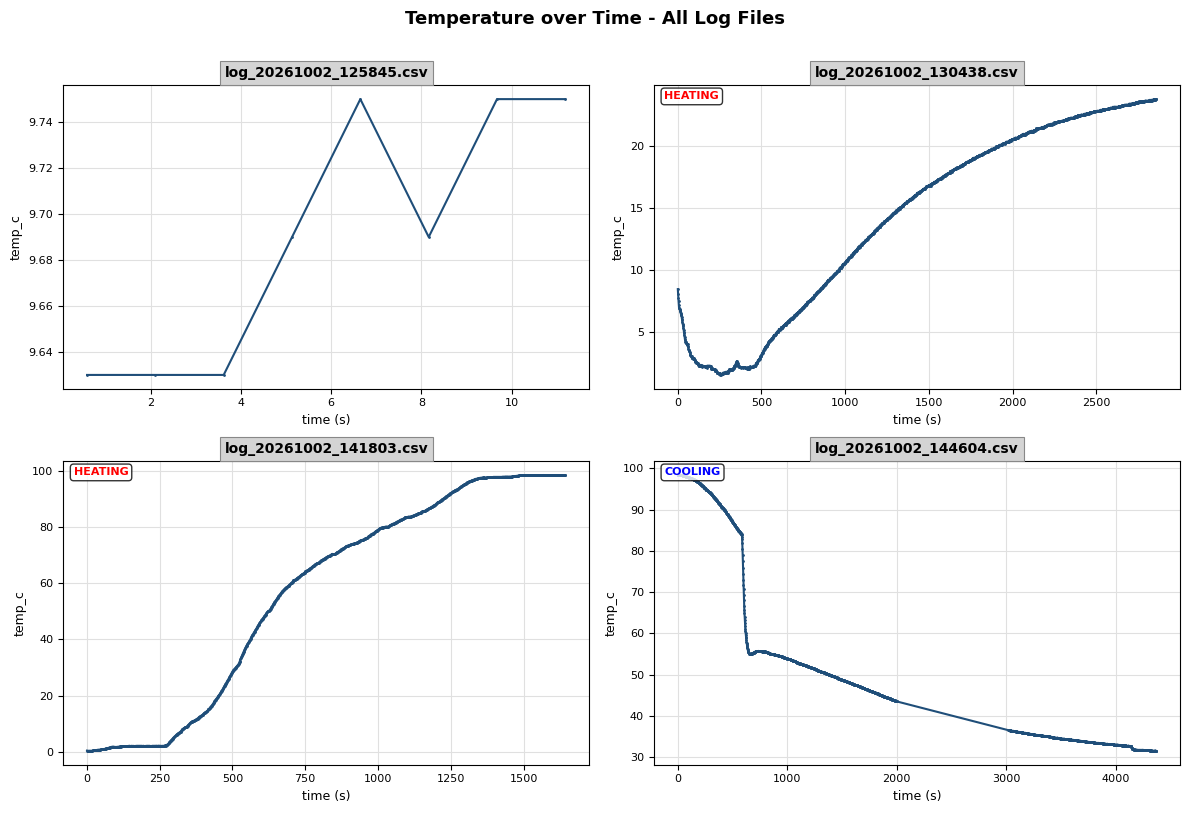


Plot saved as 'temp_vs_time_all_files.png'
Total files plotted: 4


In [151]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# List of CSV files from your git repository
csv_files = [
    "log_20261002_125845.csv",
    "log_20261002_130438.csv",
    "log_20261002_141803.csv",
    "log_20261002_144604.csv"
]

# If files are in a data folder, uncomment this:
folder_path = "../../data"
csv_files = [os.path.join(folder_path, f) for f in csv_files]

def plot_time_series_grid(file_list, n_cols=2):
    """
    Plot temp_c vs time for each file in a grid layout
    """
    n_files = len(file_list)
    if n_files == 0:
        print("No files to plot")
        return
    
    n_rows = math.ceil(n_files / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, file_path in enumerate(file_list):
        ax = axes_flat[idx]
        file_name = os.path.basename(file_path)
        
        # Read CSV file
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        # Check if required columns exist
        if 'temp_c' not in df.columns:
            print(f"Warning: 'temp_c' column not found in {file_name}")
            ax.set_title(file_name, fontsize=10, fontweight='bold',
                        pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                        facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
            ax.text(0.5, 0.5, 'No temp_c column', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12, color='red')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Plot temp_c vs time
        if 'time_ms' in df.columns:
            # Convert milliseconds to seconds
            t_sec = df['time_ms'] / 1000.0
            ax.plot(t_sec, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time (s)", fontsize=9)
        elif 'time' in df.columns:
            ax.plot(df['time'], df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("time", fontsize=9)
        else:
            # Use index as time
            ax.plot(df.index, df['temp_c'], color="#1f4e79", marker='.', markersize=2, linestyle='-')
            ax.set_xlabel("sample", fontsize=9)
        
        ax.set_ylabel("temp_c", fontsize=9)
        ax.set_title(file_name, fontsize=10, fontweight='bold',
                    pad=6, bbox=dict(boxstyle="square,pad=0.35", 
                                    facecolor="#d4d4d4", edgecolor="#888888", linewidth=0.8))
        
        # Add grid
        ax.grid(True, color="#e0e0e0", linestyle="-", linewidth=0.8)
        ax.tick_params(labelsize=8)
        
        # Determine if heating or cooling based on trend
        if len(df) > 10:
            # Compare first 10% and last 10% of data
            n_samples = len(df)
            first_avg = df['temp_c'].iloc[:n_samples//10].mean()
            last_avg = df['temp_c'].iloc[-n_samples//10:].mean()
            
            if last_avg > first_avg + 1:
                trend = "HEATING"
                color = "red"
            elif last_avg < first_avg - 1:
                trend = "COOLING"
                color = "blue"
            else:
                trend = "STABLE"
                color = "green"
            
            ax.text(0.02, 0.98, trend, transform=ax.transAxes, fontsize=8, 
                   fontweight='bold', color=color, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Hide unused subplots
    for j in range(n_files, len(axes_flat)):
        fig.delaxes(axes_flat[j])
    
    fig.suptitle("Temperature over Time - All Log Files", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("temp_vs_time_all_files.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved as 'temp_vs_time_all_files.png'")
    print(f"Total files plotted: {n_files}")

# Run the plot
print("Plotting Time-Series grid for all files...")
plot_time_series_grid(csv_files, n_cols=2)

In [152]:
# ==========================================
# 1. Define the correct file paths
# ==========================================
heating_file = "../../data/log_20261002_141803.csv"
cooling_file = "../../data/log_20261002_144604.csv"

# ==========================================
# 2. Load RAW Data
# ==========================================
# Heating
raw_heating_df = pd.read_csv(heating_file)
raw_heating_df.columns = raw_heating_df.columns.str.strip()
raw_heating_df['source'] = os.path.basename(heating_file)

# Cooling
raw_cooling_df = pd.read_csv(cooling_file)
raw_cooling_df.columns = raw_cooling_df.columns.str.strip()
raw_cooling_df['source'] = os.path.basename(cooling_file)

print(f"Raw Heating Data loaded: {len(raw_heating_df)} rows")

print(f"Raw Cooling Data loaded: {len(raw_cooling_df)} rows")

Raw Heating Data loaded: 1079 rows
Raw Cooling Data loaded: 2207 rows


In [153]:
raw_heating_df.head(3)  # Display first 3 rows of heating data


,time_ms,temp_c,temp_k,adc,source
0,596,0.44,273.59,97,log_20261002_141803.csv
1,2111,0.37,273.52,97,log_20261002_141803.csv
2,3624,0.37,273.52,96,log_20261002_141803.csv


In [154]:
raw_heating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time_ms  1079 non-null   int64  
 1   temp_c   1078 non-null   float64
 2   temp_k   1078 non-null   float64
 3   adc      1079 non-null   int64  
 4   source   1079 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 42.3+ KB


In [155]:
raw_cooling_df.head(3)  # Display first 3 rows of cooling data


,time_ms,temp_c,temp_k,adc,source
0,619,98.37,371.52,849,log_20261002_144604.csv
1,2156,98.37,371.52,849,log_20261002_144604.csv
2,3694,98.31,371.46,849,log_20261002_144604.csv


In [156]:
raw_cooling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2207 entries, 0 to 2206
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time_ms  2207 non-null   int64  
 1   temp_c   2205 non-null   float64
 2   temp_k   2205 non-null   float64
 3   adc      2207 non-null   int64  
 4   source   2207 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 86.3+ KB


In [157]:
import matplotlib.pyplot as plt

def plot_adc_vs_temp(x, y, title="ADC vs Temperature", x_label="ADC Value", y_label="Temperature (°C)", color='blue', alpha=0.5):
    """
    Plots ADC values against Temperature (°C).
    
    Parameters:
    - x: array-like, ADC values (e.g., df['adc'])
    - y: array-like, Temperature values in Celsius (e.g., df['temp_c'])
    - title: str, title of the plot
    - x_label: str, label for the x-axis
    - y_label: str, label for the y-axis
    - color: str, color of the scatter points
    - alpha: float, transparency of the scatter points (0.0 to 1.0)
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color=color, alpha=0.6, s=15, edgecolors='none')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

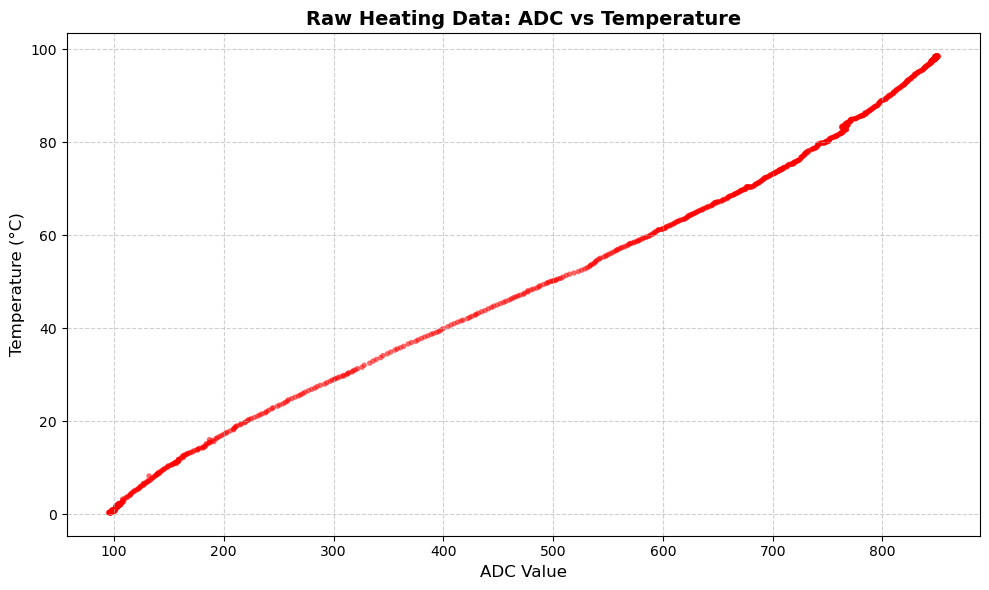

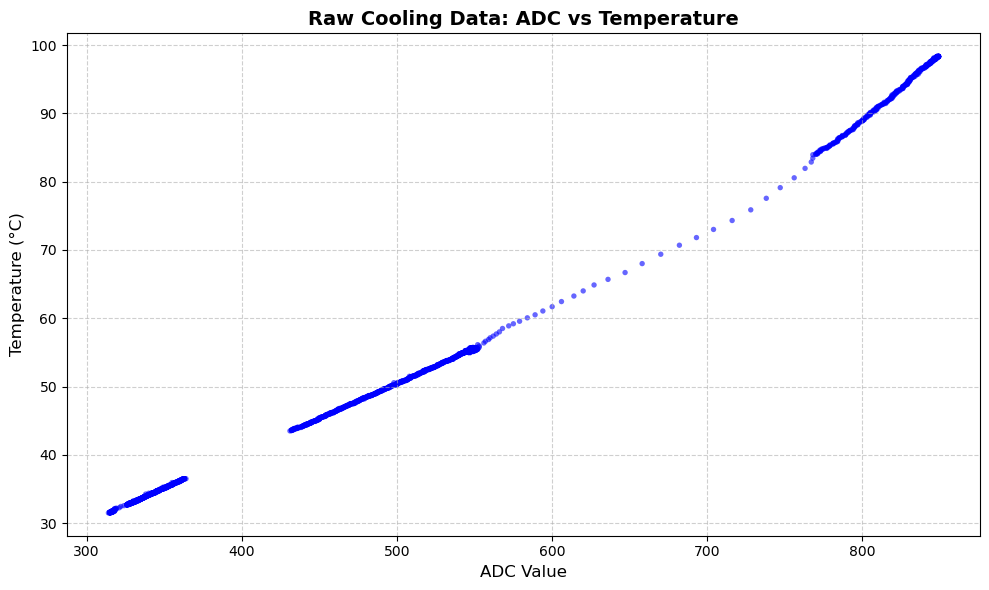

In [158]:
# 1. Plot Raw Heating Data
# Replace 'heating_df' with the actual name of your heating dataframe variable
plot_adc_vs_temp(
    x=raw_heating_df['adc'], 
    y=raw_heating_df['temp_c'], 
    title="Raw Heating Data: ADC vs Temperature", 
    color='red', 
    alpha=0.4
)

# 2. Plot Raw Cooling Data
# Replace 'cooling_df' with the actual name of your cooling dataframe variable
plot_adc_vs_temp(
    x=raw_cooling_df['adc'], 
    y=raw_cooling_df['temp_c'], 
    title="Raw Cooling Data: ADC vs Temperature", 
    color='blue', 
    alpha=0.4
)

In [159]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, max_error, r2_score
import warnings

# Suppress polynomial conditioning warnings (common and expected for high degrees, indicates overfitting)
warnings.filterwarnings('ignore', message='Polyfit may be poorly conditioned')

def analyze_polynomial_fits(df, x_col='x', y_col='y', max_degree=10):
    """
    Fits polynomial models from degree 1 to max_degree, plots the fits and residuals,
    and returns a summary table of statistics for decision making.
    
    Parameters:
    - df: pandas DataFrame containing the raw data
    - x_col: string, name of the x column (default 'x')
    - y_col: string, name of the y column (default 'y')
    - max_degree: int, maximum polynomial degree to test (default 10)
    
    Returns:
    - stats_df: pandas DataFrame containing the evaluation metrics for each degree
    """
    # Clean data (remove NaNs in x or y)
    df_clean = df.dropna(subset=[x_col, y_col]).copy()
    x = df_clean[x_col].values
    y = df_clean[y_col].values
    
    stats_list = []
    
    # Create figure: max_degree rows, 2 columns (Fit | Residuals)
    fig, axes = plt.subplots(max_degree, 2, figsize=(14, 4 * max_degree))
    
    # Generate smooth x values for plotting the polynomial curve smoothly
    x_smooth = np.linspace(x.min(), x.max(), 500)
    
    for deg in range(1, max_degree + 1):
        # 1. Fit polynomial
        coeffs = np.polyfit(x, y, deg)
        poly = np.poly1d(coeffs)
        y_pred = poly(x)
        residuals = y - y_pred
        
        # 2. Calculate statistics
        mse = mean_squared_error(y, y_pred)
        rmse = root_mean_squared_error(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        max_err = max_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        stats_list.append({
            'Degree': deg,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'Max Error': max_err,
            'R²': r2
        })
        
        # 3. Plotting
        ax_fit = axes[deg-1, 0]
        ax_res = axes[deg-1, 1]
        
        # Left: Data points ('x' markers) and Polynomial line
        ax_fit.scatter(x, y, marker='x', color='blue', alpha=0.6, label='Raw Data')
        ax_fit.plot(x_smooth, poly(x_smooth), color='red', linewidth=2, label=f'Poly Deg {deg}')
        ax_fit.set_title(f'Degree {deg} Fit (R²={r2:.4f}, RMSE={rmse:.4f})')
        ax_fit.set_xlabel(x_col)
        ax_fit.set_ylabel(y_col)
        ax_fit.legend(loc='best')
        ax_fit.grid(True, alpha=0.3)
        
        # Right: Residuals
        ax_res.scatter(x, residuals, marker='x', color='green', alpha=0.6)
        ax_res.axhline(0, color='red', linestyle='--', linewidth=1.5)
        ax_res.set_title(f'Degree {deg} Residuals')
        ax_res.set_xlabel(x_col)
        ax_res.set_ylabel('Residual (y - ŷ)')
        ax_res.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()
    
    # 4. Create and display summary table
    stats_df = pd.DataFrame(stats_list)
    
    # Format numbers for clean reading
    stats_df['MSE'] = stats_df['MSE'].map('{:.6f}'.format)
    stats_df['RMSE'] = stats_df['RMSE'].map('{:.6f}'.format)
    stats_df['MAE'] = stats_df['MAE'].map('{:.6f}'.format)
    stats_df['Max Error'] = stats_df['Max Error'].map('{:.6f}'.format)
    stats_df['R²'] = stats_df['R²'].map('{:.6f}'.format)
    
    print("\n" + "="*70)
    print(" POLYNOMIAL FIT STATISTICS SUMMARY (Degrees 1 to {})".format(max_degree))
    print("="*70)
    display(stats_df)
    print("="*70)
    print("💡 Tip: Look for the 'elbow' in RMSE/Max Error or where R² stops improving significantly.")
    print("   Higher degrees (e.g., 8-10) often overfit the noise, which you can see in the residual plots.")
    print("="*70 + "\n")
    
    return stats_df


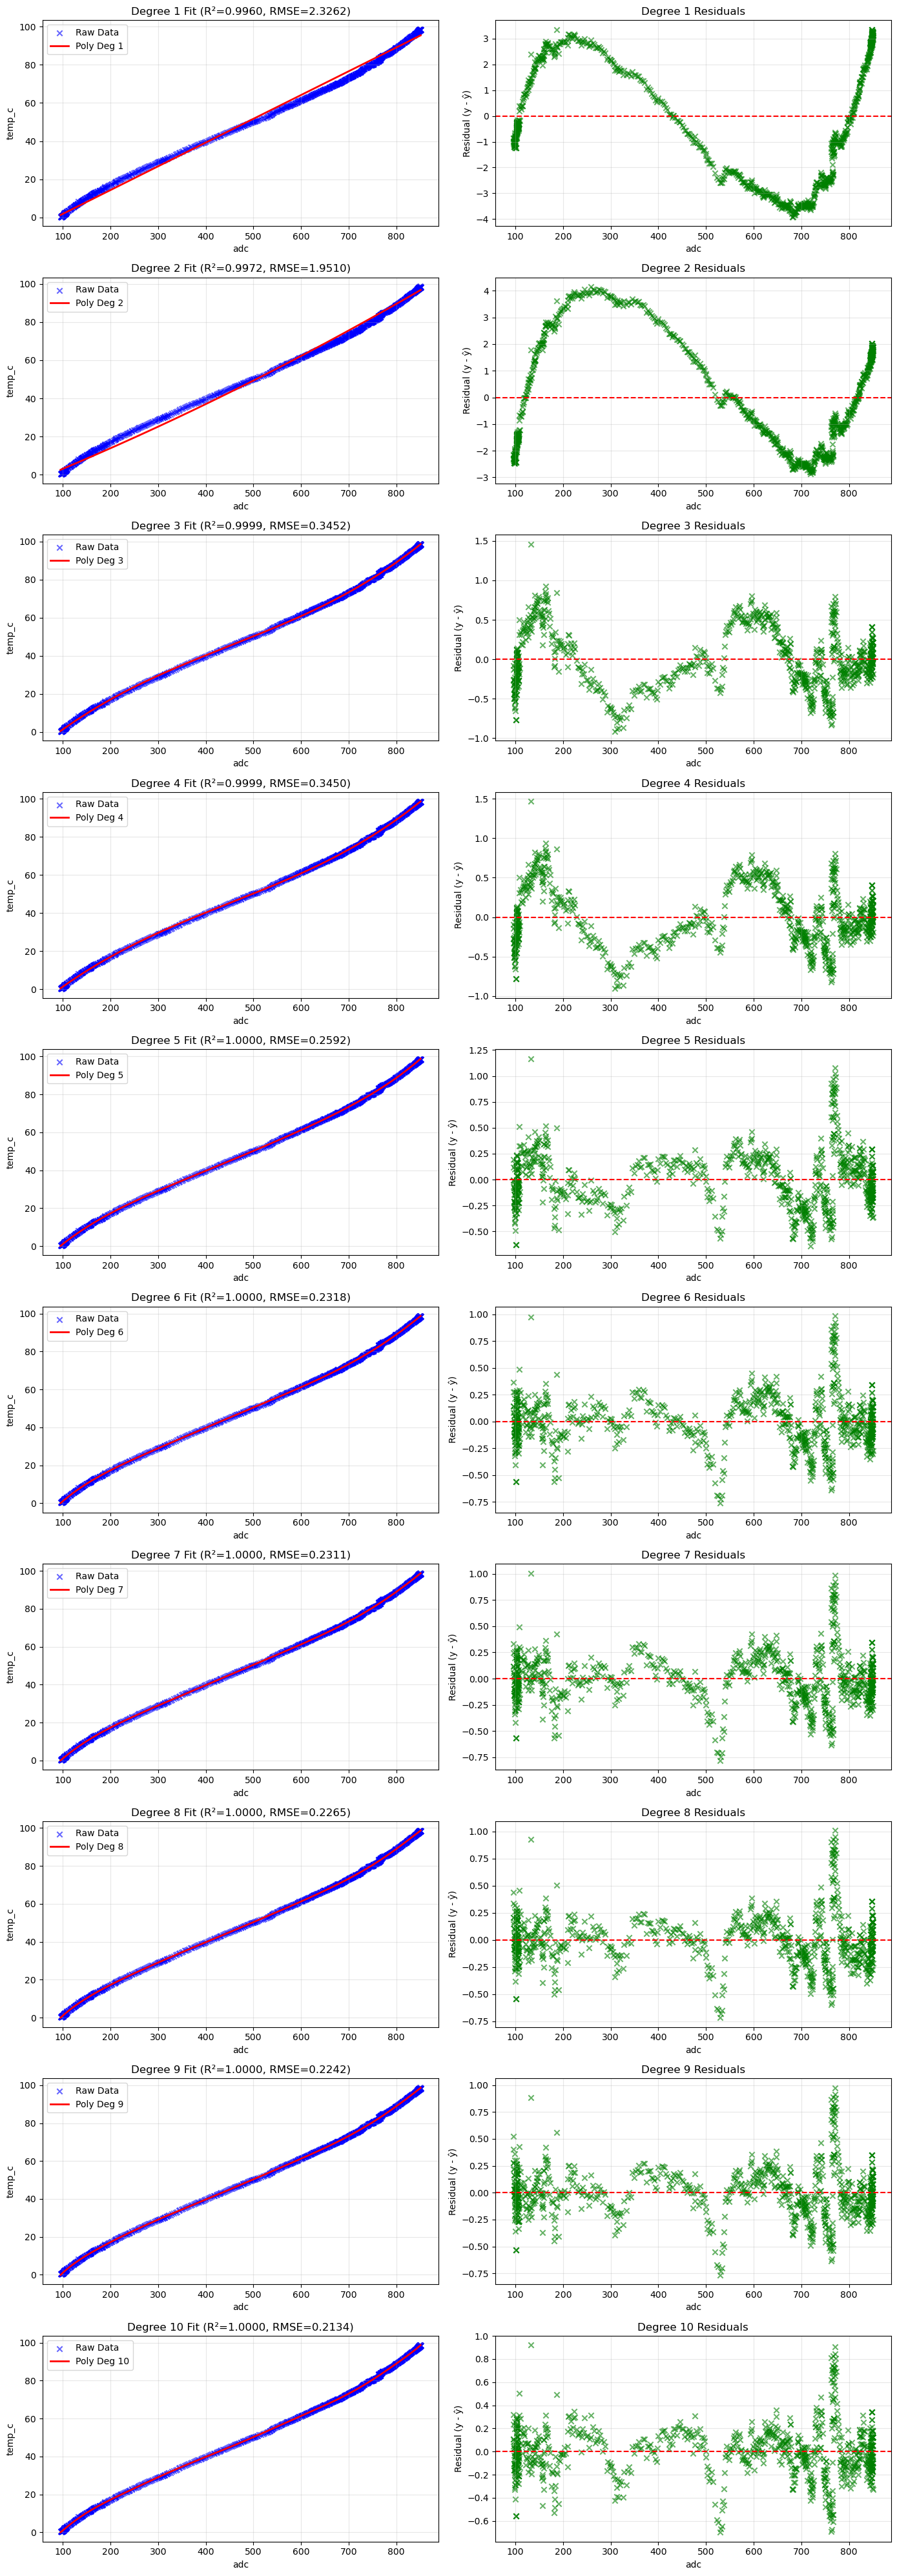


 POLYNOMIAL FIT STATISTICS SUMMARY (Degrees 1 to 10)


,Degree,MSE,RMSE,MAE,Max Error,R²
0,1,5.411166,2.326191,2.031087,3.912667,0.995997
1,2,3.806437,1.951009,1.742127,4.145559,0.997184
2,3,0.119132,0.345155,0.271607,1.459113,0.999912
3,4,0.119033,0.345012,0.271345,1.467060,0.999912
4,5,0.067178,0.259188,0.199105,1.166102,0.999950
5,6,0.053725,0.231787,0.170337,0.984844,0.999960
6,7,0.053429,0.231148,0.169322,1.004721,0.999960
7,8,0.051322,0.226544,0.165001,1.007356,0.999962
8,9,0.050285,0.224243,0.163627,0.974477,0.999963
9,10,0.045530,0.213377,0.154869,0.920184,0.999966


💡 Tip: Look for the 'elbow' in RMSE/Max Error or where R² stops improving significantly.
   Higher degrees (e.g., 8-10) often overfit the noise, which you can see in the residual plots.



In [160]:
# 1. Plot Raw Heating Data
results_table = analyze_polynomial_fits(raw_heating_df, x_col='adc', y_col='temp_c', max_degree=10)

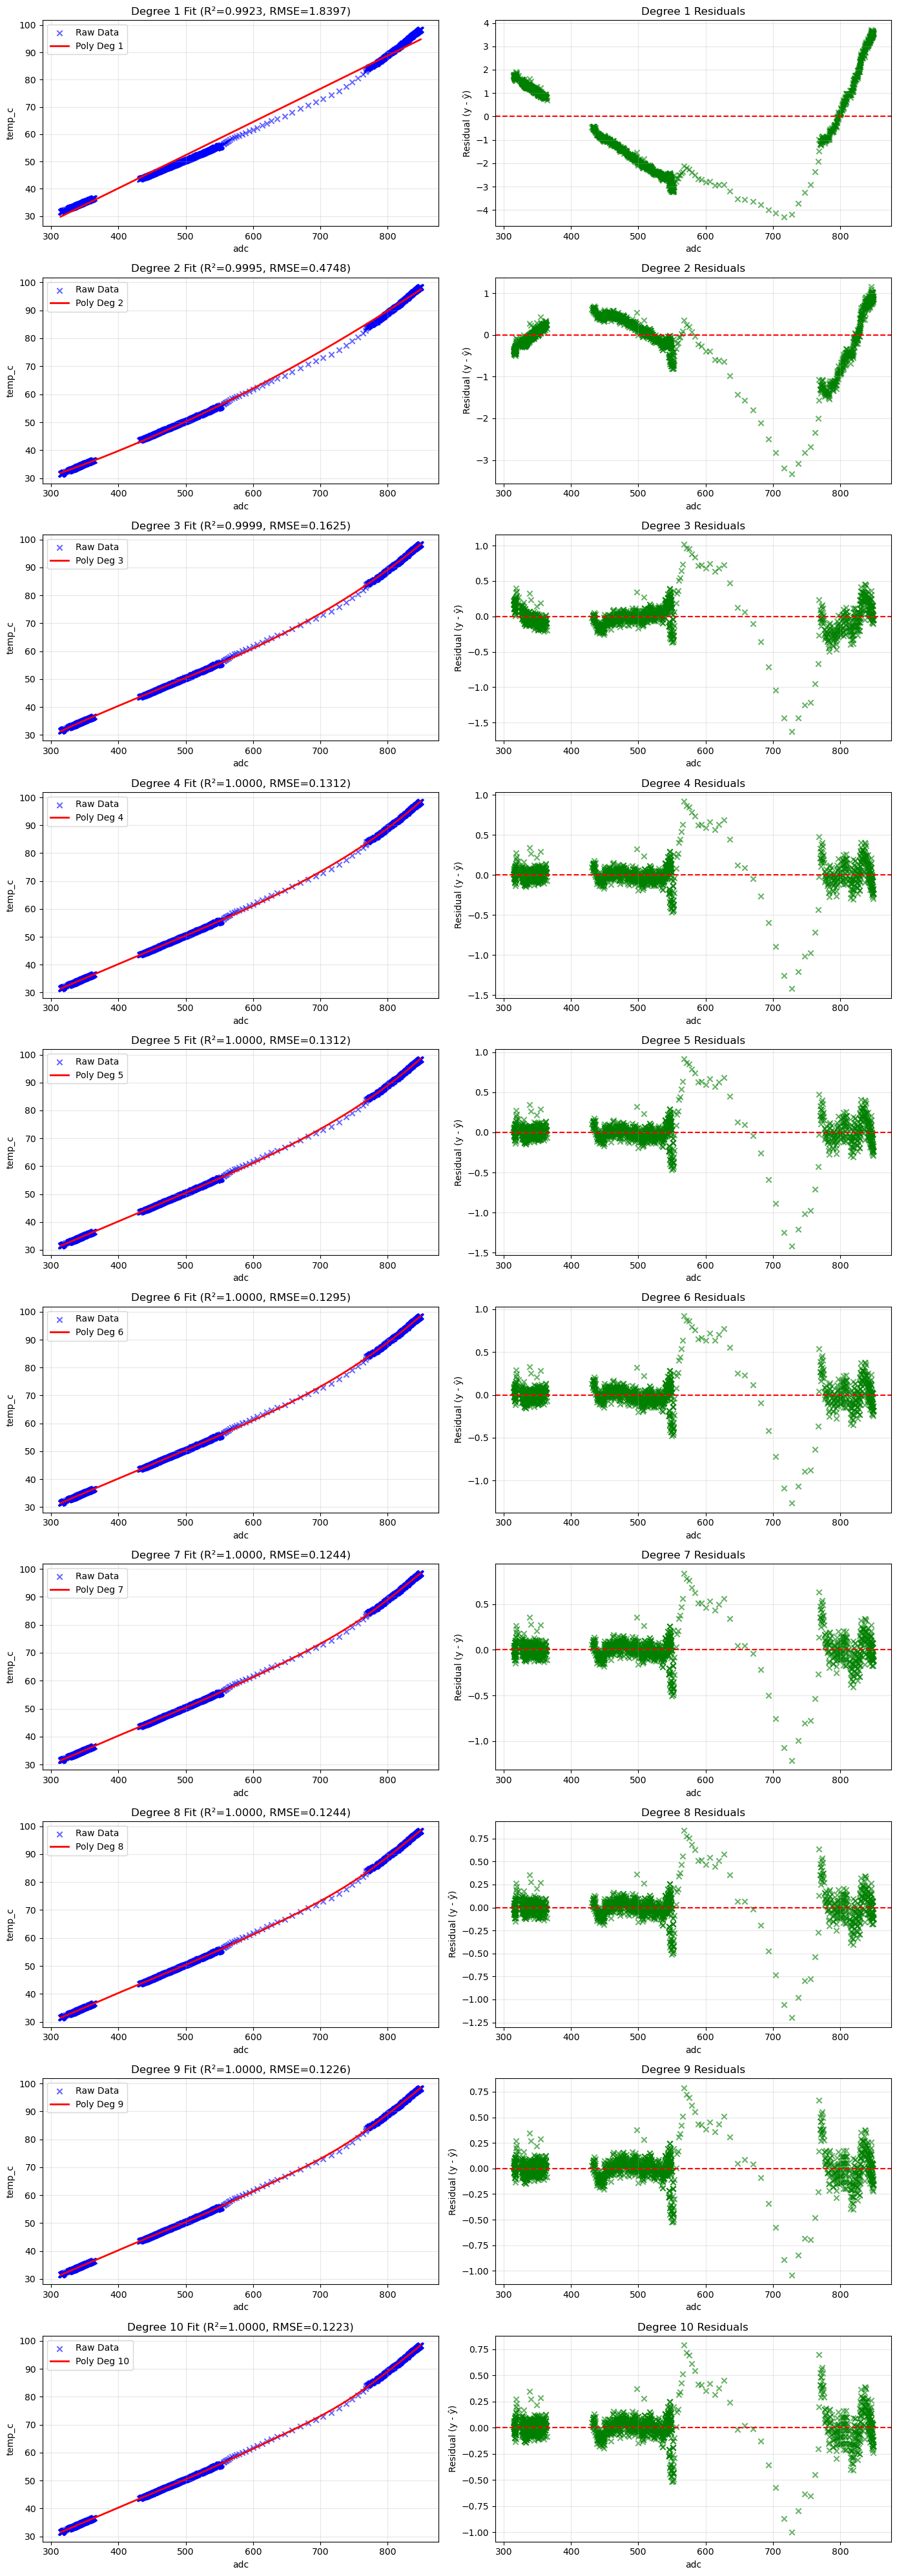


 POLYNOMIAL FIT STATISTICS SUMMARY (Degrees 1 to 10)


,Degree,MSE,RMSE,MAE,Max Error,R²
0,1,3.384563,1.839718,1.663236,4.288784,0.992297
1,2,0.225402,0.474766,0.336628,3.335649,0.999487
2,3,0.026397,0.162472,0.106508,1.623420,0.999940
3,4,0.017216,0.131210,0.076765,1.418496,0.999961
4,5,0.017215,0.131207,0.076805,1.415560,0.999961
5,6,0.016767,0.129487,0.077591,1.262877,0.999962
6,7,0.015476,0.124404,0.075040,1.211539,0.999965
7,8,0.015469,0.124376,0.075350,1.198663,0.999965
8,9,0.015022,0.122564,0.076172,1.039809,0.999966
9,10,0.014951,0.122276,0.075788,1.000414,0.999966


💡 Tip: Look for the 'elbow' in RMSE/Max Error or where R² stops improving significantly.
   Higher degrees (e.g., 8-10) often overfit the noise, which you can see in the residual plots.



In [161]:
# 1. Plot Raw Cooling Data
results_table = analyze_polynomial_fits(raw_cooling_df, x_col='adc', y_col='temp_c', max_degree=10)

In [162]:
# ==========================================
# 3. Outlier Removal Function
# ==========================================
def remove_outliers_residual(df, x_col='adc', y_col='temp_c', degree=3, sigma_mult=2.5, max_iter=3):
    """
    Iteratively removes outliers based on residuals from a polynomial fit.
    """
    # Drop any existing NaNs first
    clean_df = df.dropna(subset=[x_col, y_col]).copy()
    outliers_list = []
    
    for i in range(max_iter):
        if len(clean_df) < degree + 1:
            break
            
        x = clean_df[x_col].values
        y = clean_df[y_col].values
        
        # Fit polynomial
        coeffs = np.polyfit(x, y, degree)
        poly = np.poly1d(coeffs)
        
        # Calculate residuals
        y_pred = poly(x)
        residuals = y - y_pred
        
        # Calculate threshold (e.g., 2.5 * standard deviation)
        std_res = np.std(residuals)
        threshold = sigma_mult * std_res
        
        # Identify outliers
        outlier_mask = np.abs(residuals) > threshold
        outliers_list.append(clean_df[outlier_mask])
        
        # Keep only the inliers for the next iteration
        clean_df = clean_df[~outlier_mask]
        
        # Stop if no new outliers were found
        if not outlier_mask.any():
            break
            
    outliers_df = pd.concat(outliers_list, ignore_index=True) if outliers_list else pd.DataFrame()
    return clean_df, outliers_df


# ==========================================
# 4. Clean Data (Remove Outliers)
# ==========================================
# Clean Heating
clean_heating_df, outliers_heating_df = remove_outliers_residual(
    raw_heating_df, 
    x_col='adc', 
    y_col='temp_c', 
    degree=3, 
    sigma_mult=2.5,
    max_iter=3
)

# Clean Cooling
clean_cooling_df, outliers_cooling_df = remove_outliers_residual(
    raw_cooling_df, 
    x_col='adc', 
    y_col='temp_c', 
    degree=3, 
    sigma_mult=2.5,
    max_iter=3
)

# ==========================================
# 5. Print Cleaning Summary
# ==========================================
print("\n--- Heating Cleaning Results ---")
print(f"After cleaning: {len(clean_heating_df)} rows")
print(f"Outliers removed: {len(outliers_heating_df)} rows")

print("\n--- Cooling Cleaning Results ---")
print(f"After cleaning: {len(clean_cooling_df)} rows")
print(f"Outliers removed: {len(outliers_cooling_df)} rows")


--- Heating Cleaning Results ---
After cleaning: 1071 rows
Outliers removed: 7 rows

--- Cooling Cleaning Results ---
After cleaning: 2058 rows
Outliers removed: 147 rows


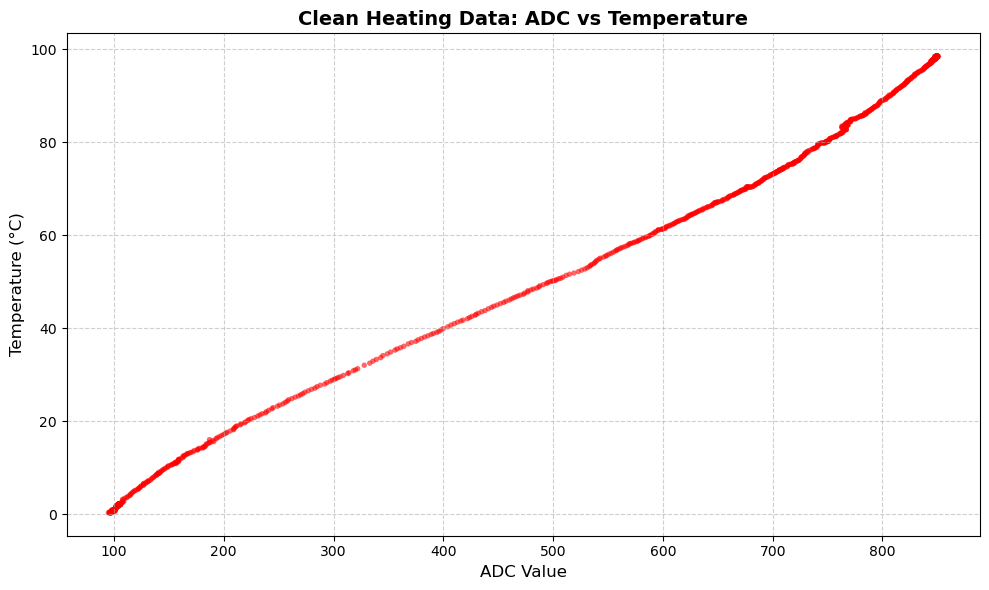

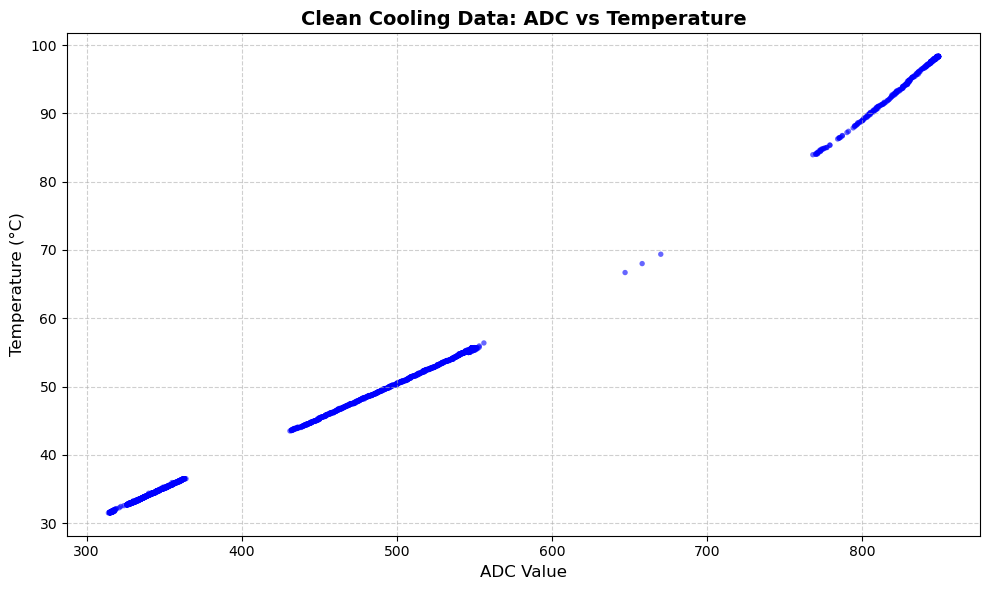

In [163]:
# 1. Plot Clean Heating Data
# Replace 'heating_df' with the actual name of your heating dataframe variable
plot_adc_vs_temp(
    x=clean_heating_df['adc'], 
    y=clean_heating_df['temp_c'], 
    title="Clean Heating Data: ADC vs Temperature", 
    color='red', 
    alpha=0.4
)

# 2. Plot Clean Cooling Data
# Replace 'cooling_df' with the actual name of your cooling dataframe variable
plot_adc_vs_temp(
    x=clean_cooling_df['adc'], 
    y=clean_cooling_df['temp_c'], 
    title="Clean Cooling Data: ADC vs Temperature", 
    color='blue', 
    alpha=0.4
)

In [164]:
# Smoothed cooling rate (°C/s) to locate the ice-cube drop
d = raw_cooling_df.dropna(subset=['adc', 'temp_c']).copy()
t = d['time_ms'] / 1000.0
rate = (d['temp_c'].diff() / t.diff()).rolling(5, center=True, min_periods=1).mean()

# The drop is where cooling is far faster than the normal slow decay
drop = d[rate < -0.2]            # tune the threshold if needed
t_start = drop['time_ms'].min()  # drop begins
t_end = drop['time_ms'].max()    # drop has finished

# Padding so the settling tail is excluded from both sets
pad_ms = 30_000                  # 30 s each side; adjust after looking at the plot

upper_raw_cooling_df  = d[d['time_ms'] < t_start - pad_ms].copy()   # before the ice
bottom_raw_cooling_df = d[d['time_ms'] > t_end + pad_ms].copy()     # after the ice

print(f"Drop window: {t_start/1000:.0f}s to {t_end/1000:.0f}s")
print(f"Upper : {len(upper_raw_cooling_df)} rows, "
      f"{upper_raw_cooling_df['temp_c'].max():.1f} to {upper_raw_cooling_df['temp_c'].min():.1f} °C")
print(f"Bottom: {len(bottom_raw_cooling_df)} rows, "
      f"{bottom_raw_cooling_df['temp_c'].max():.1f} to {bottom_raw_cooling_df['temp_c'].min():.1f} °C")

Drop window: 587s to 631s
Upper : 363 rows, 98.4 to 84.9 °C
Bottom: 1775 rows, 55.8 to 31.5 °C


In [165]:
clean_upper_cooling_df, outliers_upper = remove_outliers_residual(upper_raw_cooling_df, 'adc', 'temp_c', degree=3, sigma_mult=2.5, max_iter=3)
clean_bottom_cooling_df, outliers_bottom = remove_outliers_residual(bottom_raw_cooling_df, 'adc', 'temp_c', degree=3, sigma_mult=2.5, max_iter=3)

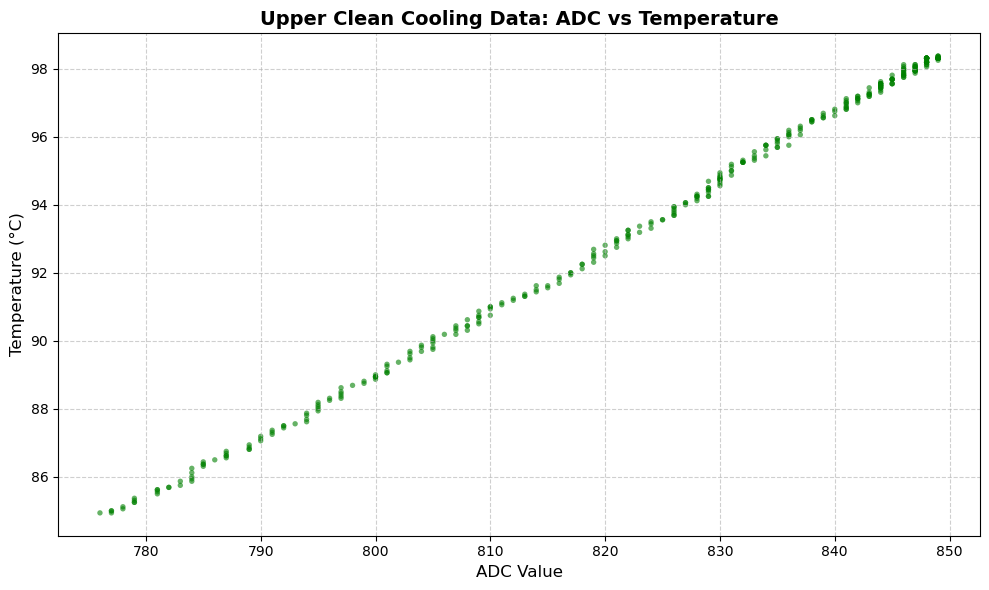

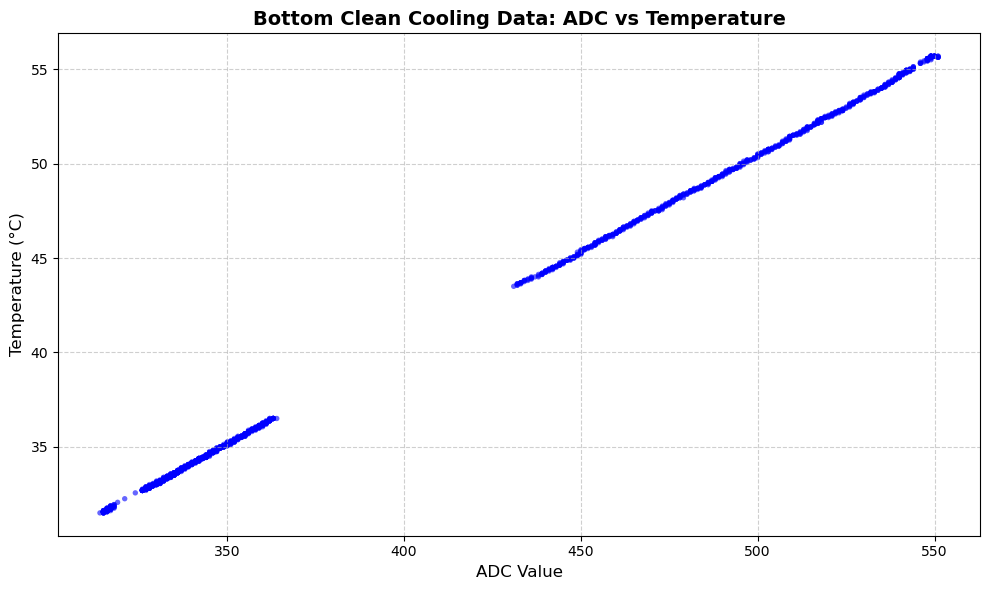

In [166]:
# 3. Plot Upper Clean Heating Data
plot_adc_vs_temp(
    x=clean_upper_cooling_df['adc'], 
    y=clean_upper_cooling_df['temp_c'], 
    title="Upper Clean Cooling Data: ADC vs Temperature", 
    color='green', 
    alpha=0.4
)

# 4. Plot Bottom Clean Cooling Data
plot_adc_vs_temp(
    x=clean_bottom_cooling_df['adc'], 
    y=clean_bottom_cooling_df['temp_c'], 
    title="Bottom Clean Cooling Data: ADC vs Temperature", 
    color='blue', 
    alpha=0.4
)

In [167]:
DEG = 3
datasets = {
    "Heating":        (clean_heating_df,        "#d9534f", "o"),
    "Cooling (upper)": (clean_upper_cooling_df,  "#1f77b4", "^"),
    "Cooling (bottom)": (clean_bottom_cooling_df, "#2ca02c", "s"),
}

# ------------------------------------------------------------
# 1. Fit a cubic to each dataset and collect fit statistics
# ------------------------------------------------------------
fits, rows = {}, []
for name, (df, _, _) in datasets.items():
    x, y = df['adc'].values, df['temp_c'].values
    poly = np.poly1d(np.polyfit(x, y, DEG))
    y_pred = poly(x)
    fits[name] = poly
    rows.append({
        "Dataset": name,
        "N": len(df),
        "ADC range": f"{x.min():.0f} - {x.max():.0f}",
        "Temp range (°C)": f"{y.min():.1f} - {y.max():.1f}",
        "R²": f"{r2_score(y, y_pred):.5f}",
        "RMSE (°C)": f"{root_mean_squared_error(y, y_pred):.3f}",
        "Max err (°C)": f"{max_error(y, y_pred):.3f}",
    })

print("=" * 85)
print(f"DEGREE-{DEG} FIT STATISTICS")
print(pd.DataFrame(rows).to_string(index=False))
print("\nCoefficients (highest power first):")
for name, poly in fits.items():
    print(f"  {name:17s}: " + ", ".join(f"{c:.4e}" for c in poly.coeffs))


DEGREE-3 FIT STATISTICS
         Dataset    N ADC range Temp range (°C)      R² RMSE (°C) Max err (°C)
         Heating 1071  95 - 851      0.3 - 98.5 0.99992     0.337        0.839
 Cooling (upper)  354 776 - 849     84.9 - 98.4 0.99919     0.119        0.292
Cooling (bottom) 1681 314 - 551     31.5 - 55.7 0.99996     0.057        0.143

Coefficients (highest power first):
  Heating          : 2.1134e-07, -2.8582e-04, 2.2822e-01, -1.8844e+01
  Cooling (upper)  : -5.8254e-06, 1.4444e-02, -1.1740e+01, 3.2197e+03
  Cooling (bottom) : 9.0017e-08, -1.1280e-04, 1.4854e-01, -6.8841e+00


In [168]:
# ------------------------------------------------------------
# 2. Hysteresis: heating minus cooling, only where ADC ranges overlap
#    (a) from the fitted cubics, (b) model-free from the cleaned data
# ------------------------------------------------------------
heat_df = datasets["Heating"][0]
heat_mean = heat_df.groupby('adc')['temp_c'].mean()     # one temp per ADC value
heat_adc, heat_temp = heat_mean.index.values, heat_mean.values

print("\n" + "=" * 85)
print("HYSTERESIS  (ΔT = T_heating - T_cooling at the same ADC)")
hyst_rows = []
for name in ["Cooling (upper)", "Cooling (bottom)"]:
    cdf = datasets[name][0]
    lo = max(heat_df['adc'].min(), cdf['adc'].min())
    hi = min(heat_df['adc'].max(), cdf['adc'].max())

    # (a) fit vs fit
    grid = np.linspace(lo, hi, 300)
    d_fit = fits["Heating"](grid) - fits[name](grid)

    # (b) model-free: heating temperature interpolated at each cooling point's ADC
    m = (cdf['adc'] >= lo) & (cdf['adc'] <= hi)
    t_heat_at_cool = np.interp(cdf.loc[m, 'adc'].values, heat_adc, heat_temp)
    d_data = t_heat_at_cool - cdf.loc[m, 'temp_c'].values

    hyst_rows.append({
        "Cooling set": name,
        "Overlap ADC": f"{lo:.0f} - {hi:.0f}",
        "Fit: mean ΔT": f"{d_fit.mean():+.2f}",
        "Fit: mean |ΔT|": f"{np.abs(d_fit).mean():.2f}",
        "Fit: max |ΔT|": f"{np.abs(d_fit).max():.2f} @ ADC {grid[np.abs(d_fit).argmax()]:.0f}",
        "Data: mean ΔT": f"{d_data.mean():+.2f}",
        "Data: mean |ΔT|": f"{np.abs(d_data).mean():.2f}",
        "Data: max |ΔT|": f"{np.abs(d_data).max():.2f}",
    })
print(pd.DataFrame(hyst_rows).to_string(index=False))
print("=" * 85)


HYSTERESIS  (ΔT = T_heating - T_cooling at the same ADC)
     Cooling set Overlap ADC Fit: mean ΔT Fit: mean |ΔT|  Fit: max |ΔT| Data: mean ΔT Data: mean |ΔT| Data: max |ΔT|
 Cooling (upper)   776 - 849        -0.05           0.14 0.25 @ ADC 839         -0.17            0.22           0.69
Cooling (bottom)   314 - 551        -0.12           0.12 0.29 @ ADC 551         -0.49            0.50           1.11


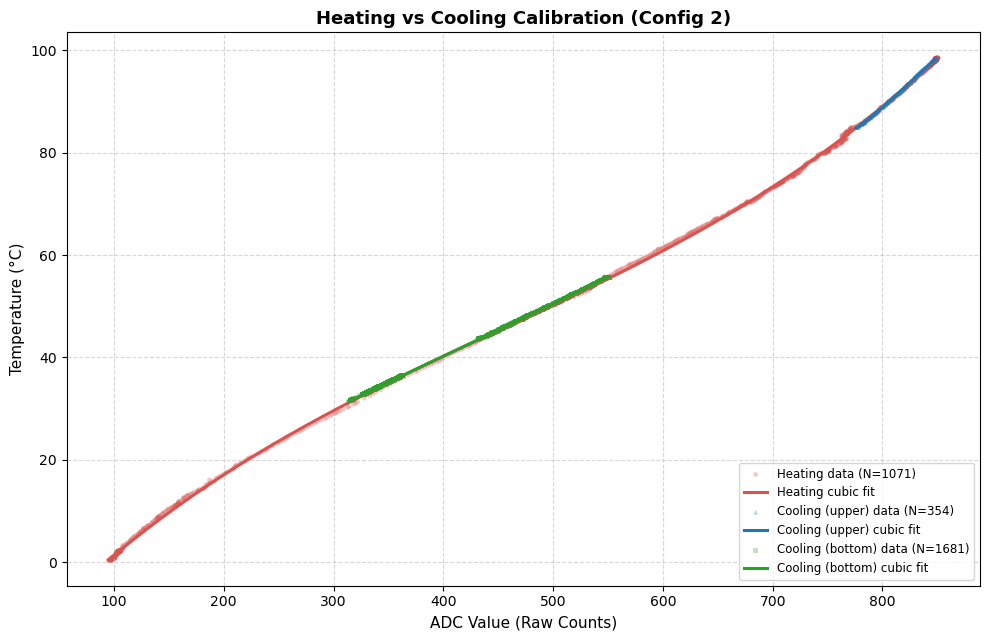

In [169]:

# ------------------------------------------------------------
# 3. Graph: data + cubic fit lines for all three sets
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.5))
for name, (df, color, marker) in datasets.items():
    ax.scatter(df['adc'], df['temp_c'], color=color, marker=marker, s=12, alpha=0.30,
               edgecolors='none', label=f"{name} data (N={len(df)})")
    xs = np.linspace(df['adc'].min(), df['adc'].max(), 300)
    ax.plot(xs, fits[name](xs), color=color, linewidth=2.2, label=f"{name} cubic fit")

ax.set_xlabel("ADC Value (Raw Counts)", fontsize=11)
ax.set_ylabel("Temperature (°C)", fontsize=11)
ax.set_title("Heating vs Cooling Calibration (Config 2)", fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.show()

In [170]:
import statsmodels.api as sm

# ------------------------------------------------------------
# 1. Pool the three clean datasets (justified: hysteresis ≈ 0.5 °C, near reference accuracy)
# ------------------------------------------------------------
parts = {
    "Heating":          clean_heating_df,
    "Cooling (upper)":  clean_upper_cooling_df,
    "Cooling (bottom)": clean_bottom_cooling_df,
}
comb_df = pd.concat(
    [df[['adc', 'temp_c']].assign(source=name) for name, df in parts.items()],
    ignore_index=True
)


In [171]:

# ------------------------------------------------------------
# 2. Cubic OLS on scaled ADC (avoids the 1e10 condition number), 95% prediction interval
# ------------------------------------------------------------
X0, S = 500.0, 100.0
def design(adc):
    z = (np.asarray(adc, float) - X0) / S
    return sm.add_constant(np.column_stack([z, z**2, z**3]), has_constant='add')

model = sm.OLS(comb_df['temp_c'].values, design(comb_df['adc'])).fit()

grid = np.linspace(comb_df['adc'].min(), comb_df['adc'].max(), 400)
pred = model.get_prediction(design(grid)).summary_frame(alpha=0.05)
t_fit, lo, hi = pred['mean'], pred['obs_ci_lower'], pred['obs_ci_upper']
half_width = (hi - lo) / 2

# Same cubic expressed in raw ADC counts (for the report / firmware)
c3, c2, c1, c0 = np.polyfit(comb_df['adc'], comb_df['temp_c'], 3)


In [172]:
# ------------------------------------------------------------
# 3. Statistics
# ------------------------------------------------------------
y = comb_df['temp_c'].values
y_hat = model.predict(design(comb_df['adc']))
comb_df['resid'] = y - y_hat

print("=" * 80)
print("FINAL CALIBRATION EQUATION (pooled heating + cooling, degree 3):")
print(f"T(ADC) = ({c3:.4e})·ADC³ + ({c2:.4e})·ADC² + ({c1:.4e})·ADC + ({c0:.4f})")
print(f"95% prediction interval: mean ±{half_width.mean():.2f} °C "
      f"(min ±{half_width.min():.2f}, max ±{half_width.max():.2f})")
print("=" * 80)
print(f"N = {len(y)} | R² = {r2_score(y, y_hat):.5f} | "
      f"RMSE = {root_mean_squared_error(y, y_hat):.3f} °C | "
      f"Max error = {max_error(y, y_hat):.3f} °C")
print(f"ADC range = {comb_df['adc'].min()} - {comb_df['adc'].max()} | "
      f"Temp range = {y.min():.1f} - {y.max():.1f} °C\n")

print("Residual check per source (bias = mean residual, should be near 0):")
print(comb_df.groupby('source')['resid']
      .agg(N='count', bias='mean', rmse=lambda r: np.sqrt((r**2).mean()),
           max_abs=lambda r: r.abs().max()).round(3).to_string())
print("=" * 80)

FINAL CALIBRATION EQUATION (pooled heating + cooling, degree 3):
T(ADC) = (2.1266e-07)·ADC³ + (-2.8857e-04)·ADC² + (2.2985e-01)·ADC + (-19.0074)
95% prediction interval: mean ±0.44 °C (min ±0.44, max ±0.44)
N = 3106 | R² = 0.99993 | RMSE = 0.226 °C | Max error = 0.937 °C
ADC range = 95 - 851 | Temp range = 0.3 - 98.5 °C

Residual check per source (bias = mean residual, should be near 0):
                     N   bias   rmse  max_abs
source                                       
Cooling (bottom)  1681  0.024  0.101    0.299
Cooling (upper)    354  0.057  0.199    0.466
Heating           1071 -0.057  0.345    0.937


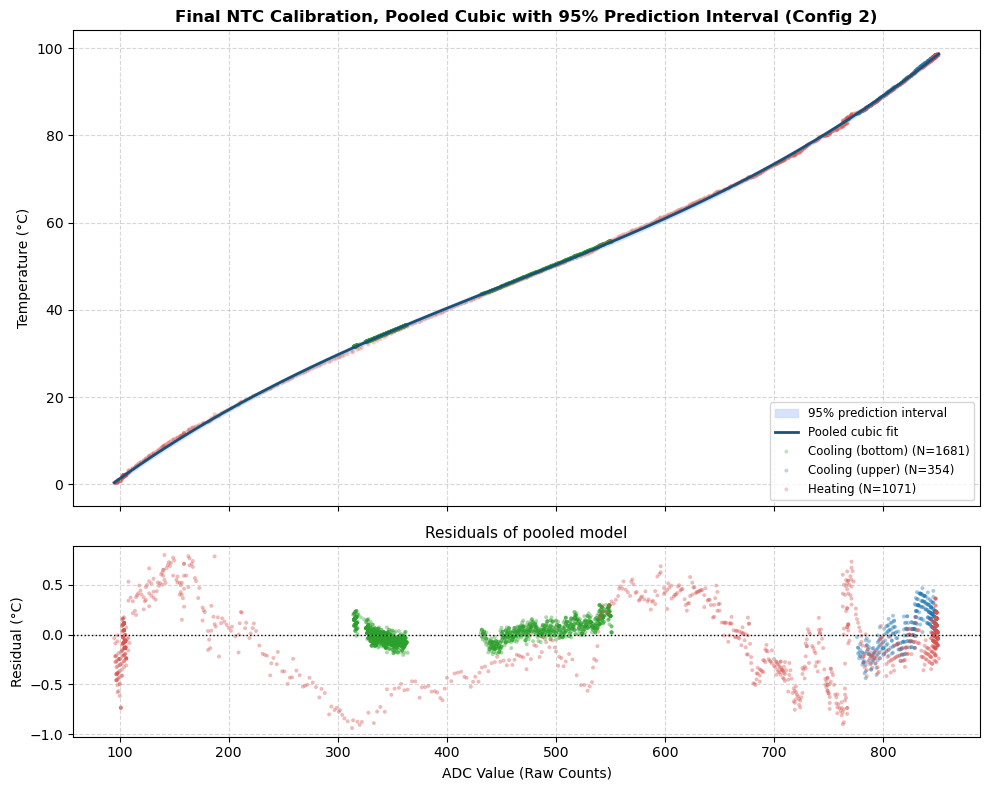

In [173]:
# ------------------------------------------------------------
# 4. Plot: fit + 95% prediction band, and residuals underneath
# ------------------------------------------------------------
colors = {"Heating": "#d9534f", "Cooling (upper)": "#1f77b4", "Cooling (bottom)": "#2ca02c"}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                               gridspec_kw={'height_ratios': [2.5, 1]})

ax1.fill_between(grid, lo, hi, color='#c8d8f8', alpha=0.7, label='95% prediction interval')
ax1.plot(grid, t_fit, color='#1a5276', linewidth=2, label='Pooled cubic fit')
for name, g in comb_df.groupby('source'):
    ax1.scatter(g['adc'], g['temp_c'], s=8, alpha=0.3, color=colors[name],
                edgecolors='none', label=f'{name} (N={len(g)})')
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Final NTC Calibration, Pooled Cubic with 95% Prediction Interval (Config 2)",
              fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', fontsize=8.5)

for name, g in comb_df.groupby('source'):
    ax2.scatter(g['adc'], g['resid'], s=8, alpha=0.4, color=colors[name], edgecolors='none')
ax2.axhline(0, color='black', linestyle=':', linewidth=1)
ax2.set_xlabel("ADC Value (Raw Counts)")
ax2.set_ylabel("Residual (°C)")
ax2.set_title("Residuals of pooled model", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error, max_error

ADC_MAX = 1023.0
T0 = 298.15           # 25 °C in K
R_FIXED = None        # set to the fixed resistor in ohms (e.g. 3300) to also get R25; leave None otherwise

# ------------------------------------------------------------
# 1. Define the datasets: three main fits + two segment diagnostics
# ------------------------------------------------------------
cool_full = pd.concat([clean_upper_cooling_df, clean_bottom_cooling_df], ignore_index=True)
pooled    = pd.concat([clean_heating_df, cool_full], ignore_index=True)

main_sets = {
    "Heating (full)":  clean_heating_df,
    "Cooling (full)":  cool_full,
    "Pooled":          pooled,
}
segment_sets = {
    "Cooling (upper)":  clean_upper_cooling_df,
    "Cooling (bottom)": clean_bottom_cooling_df,
}
all_sets = {**main_sets, **segment_sets}

In [175]:

# ------------------------------------------------------------
# 2. Beta-model fit for one dataset
#    ln(r) = beta * (1/T) + c        (beta = slope, c = ln(R0/Rfixed) - beta/T0)
#    prediction: 1/T = A*ln(r) + B   (fitted directly, so error is minimised in 1/T)
# ------------------------------------------------------------
def fit_beta(df):
    adc = np.clip(df['adc'].values.astype(float), 1, ADC_MAX - 1)
    t_c = df['temp_c'].values
    ln_r = np.log((ADC_MAX - adc) / adc)
    inv_T = 1.0 / (t_c + 273.15)

    beta, c = np.polyfit(inv_T, ln_r, 1)               # physical constant
    A, B = np.polyfit(ln_r, inv_T, 1)                  # calibration form
    t_pred = 1.0 / (A * ln_r + B) - 273.15

    r2_lin = r2_score(ln_r, beta * inv_T + c)          # quality in linearised space
    rmse = root_mean_squared_error(t_c, t_pred)
    mx = max_error(t_c, t_pred)

    # cubic on the same data, for comparison
    cub = np.poly1d(np.polyfit(df['adc'].values, t_c, 3))
    rmse_cub = root_mean_squared_error(t_c, cub(df['adc'].values))

    r25 = np.exp(c + beta / T0)                        # R25 / R_fixed
    return dict(beta=beta, c=c, A=A, B=B, r2_lin=r2_lin, rmse=rmse, max_err=mx,
                rmse_cubic=rmse_cub, r25_ratio=r25, ln_r=ln_r, inv_T=inv_T,
                t_c=t_c, t_pred=t_pred, n=len(df),
                t_min=t_c.min(), t_max=t_c.max())

results = {name: fit_beta(df) for name, df in all_sets.items()}

In [176]:
# ------------------------------------------------------------
# 3. Summary table
# ------------------------------------------------------------
rows = []
for name, r in results.items():
    row = {
        "Dataset": name,
        "N": r['n'],
        "Temp range (°C)": f"{r['t_min']:.1f} - {r['t_max']:.1f}",
        "β (K)": f"{r['beta']:.1f}",
        "R² (ln r vs 1/T)": f"{r['r2_lin']:.5f}",
        "β-model RMSE (°C)": f"{r['rmse']:.3f}",
        "β-model max err (°C)": f"{r['max_err']:.3f}",
        "Cubic RMSE (°C)": f"{r['rmse_cubic']:.3f}",
        "R25/R_fixed": f"{r['r25_ratio']:.3f}",
    }
    if R_FIXED:
        row["R25 (Ω)"] = f"{r['r25_ratio'] * R_FIXED:.0f}"
    rows.append(row)

print("=" * 110)
print("PHYSICAL NTC β-MODEL FITS")
print(pd.DataFrame(rows).to_string(index=False))
print("\nCalibration form per dataset:  1/T[K] = A·ln((1023-ADC)/ADC) + B")
for name, r in results.items():
    print(f"  {name:17s}: A = {r['A']:.5e}   B = {r['B']:.5e}")

# Do the segments agree with the full-range β?
b_full = results["Pooled"]['beta']
print("\nβ consistency check (relative to pooled β):")
for name, r in results.items():
    print(f"  {name:17s}: {r['beta']:8.1f} K  ({100*(r['beta']-b_full)/b_full:+.1f} %)")
print("=" * 110)


PHYSICAL NTC β-MODEL FITS
         Dataset    N Temp range (°C)  β (K) R² (ln r vs 1/T) β-model RMSE (°C) β-model max err (°C) Cubic RMSE (°C) R25/R_fixed
  Heating (full) 1071      0.3 - 98.5 3972.6          0.99985             0.534                1.351           0.337       2.910
  Cooling (full) 2035     31.5 - 98.4 4025.5          0.99994             0.176                0.800           0.116       3.008
          Pooled 3106      0.3 - 98.5 3992.4          0.99976             0.432                1.329           0.226       2.963
 Cooling (upper)  354     84.9 - 98.4 4277.3          0.99845             0.166                0.402           0.119       3.511
Cooling (bottom) 1681     31.5 - 55.7 3979.4          0.99995             0.060                0.174           0.057       2.986

Calibration form per dataset:  1/T[K] = A·ln((1023-ADC)/ADC) + B
  Heating (full)   : A = 2.51688e-04   B = 3.08517e-03
  Cooling (full)   : A = 2.48399e-04   B = 3.08044e-03
  Pooled           : A =

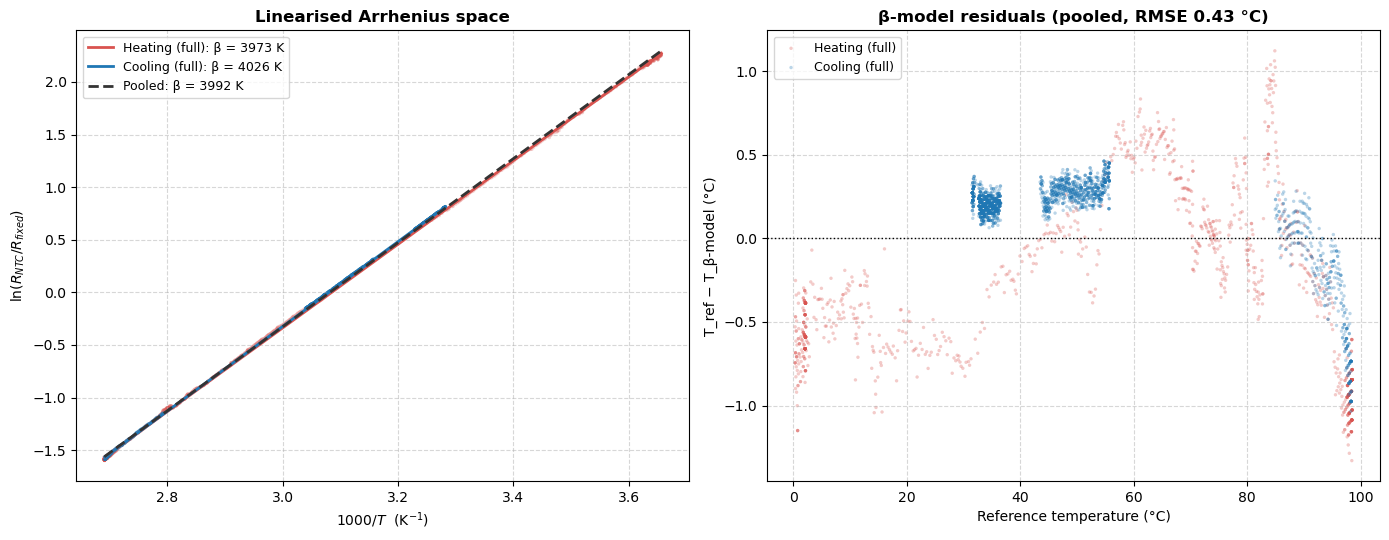

In [180]:
# ------------------------------------------------------------
# 4. Plots: linearised space, and β-model residuals vs temperature
# ------------------------------------------------------------
colors = {"Heating (full)": "#d9534f", "Cooling (full)": "#1f77b4", "Pooled": "#333333",
          "Cooling (upper)": "#8e44ad", "Cooling (bottom)": "#2ca02c"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) ln r vs 1000/T, data + straight-line fit for each of the three main sets
for name in main_sets:
    r = results[name]
    if name != "Pooled":
        ax1.scatter(r['inv_T'] * 1000, r['ln_r'], s=6, alpha=0.25, color=colors[name],
                    edgecolors='none')
    xs = np.linspace(r['inv_T'].min(), r['inv_T'].max(), 100)
    ax1.plot(xs * 1000, r['beta'] * xs + r['c'], color=colors[name], linewidth=2,
             linestyle='-' if name != "Pooled" else '--',
             label=f"{name}: β = {r['beta']:.0f} K")
ax1.set_xlabel(r"$1000 / T$  (K$^{-1}$)")
ax1.set_ylabel(r"$\ln(R_{NTC}/R_{fixed})$")
ax1.set_title("Linearised Arrhenius space", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=9)


# (b) residuals of the β-model in °C vs reference temperature (pooled), curvature shows up here
rp = results["Pooled"]
src = np.concatenate([np.full(len(clean_heating_df), "Heating (full)"),
                      np.full(len(cool_full), "Cooling (full)")])
res = rp['t_c'] - rp['t_pred']
for name in ["Heating (full)", "Cooling (full)"]:
    m = src == name
    ax2.scatter(rp['t_c'][m], res[m], s=6, alpha=0.3, color=colors[name], edgecolors='none',
                label=name)
ax2.axhline(0, color='black', linestyle=':', linewidth=1)
ax2.set_xlabel("Reference temperature (°C)")
ax2.set_ylabel("T_ref − T_β-model (°C)")
ax2.set_title(f"β-model residuals (pooled, RMSE {rp['rmse']:.2f} °C)", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()